# Nuages de mots

## Imports et stopwords

In [3]:
from pathlib import Path
import pandas as pd
from wordcloud import WordCloud
from IPython.display import Image, display  

ROOT = Path.cwd().parent
CSV  = ROOT / "output" / "keywords" / "keywords_1950.csv"
FIGS = ROOT / "figs"
FIGS.mkdir(parents=True, exist_ok=True)
OUT_PNG = FIGS / "wordcloud_1950.png"


In [4]:
df = pd.read_csv(CSV)

df["weight"] = 1.0 / (df["score"] + 1e-9)

g = (
    df.dropna(subset=["keyword"])
      .assign(keyword=lambda d: d["keyword"].astype(str).str.strip())
      .groupby("keyword", as_index=False)["weight"].sum()
)

freq = dict(zip(g["keyword"], g["weight"]))

len(freq), list(freq.items())[:5]  # petit aperçu


(737,
 [('ACOMPTE MINIME', 16.487715216939492),
  ('AGENCE ROSSEL', 330.82619323280346),
  ('ALFA ROMÉO', 78.82139434587496),
  ('ANCIENNE MAISON', 19.63728511361797),
  ('ANDREE Tél', 26.615355486501205)])

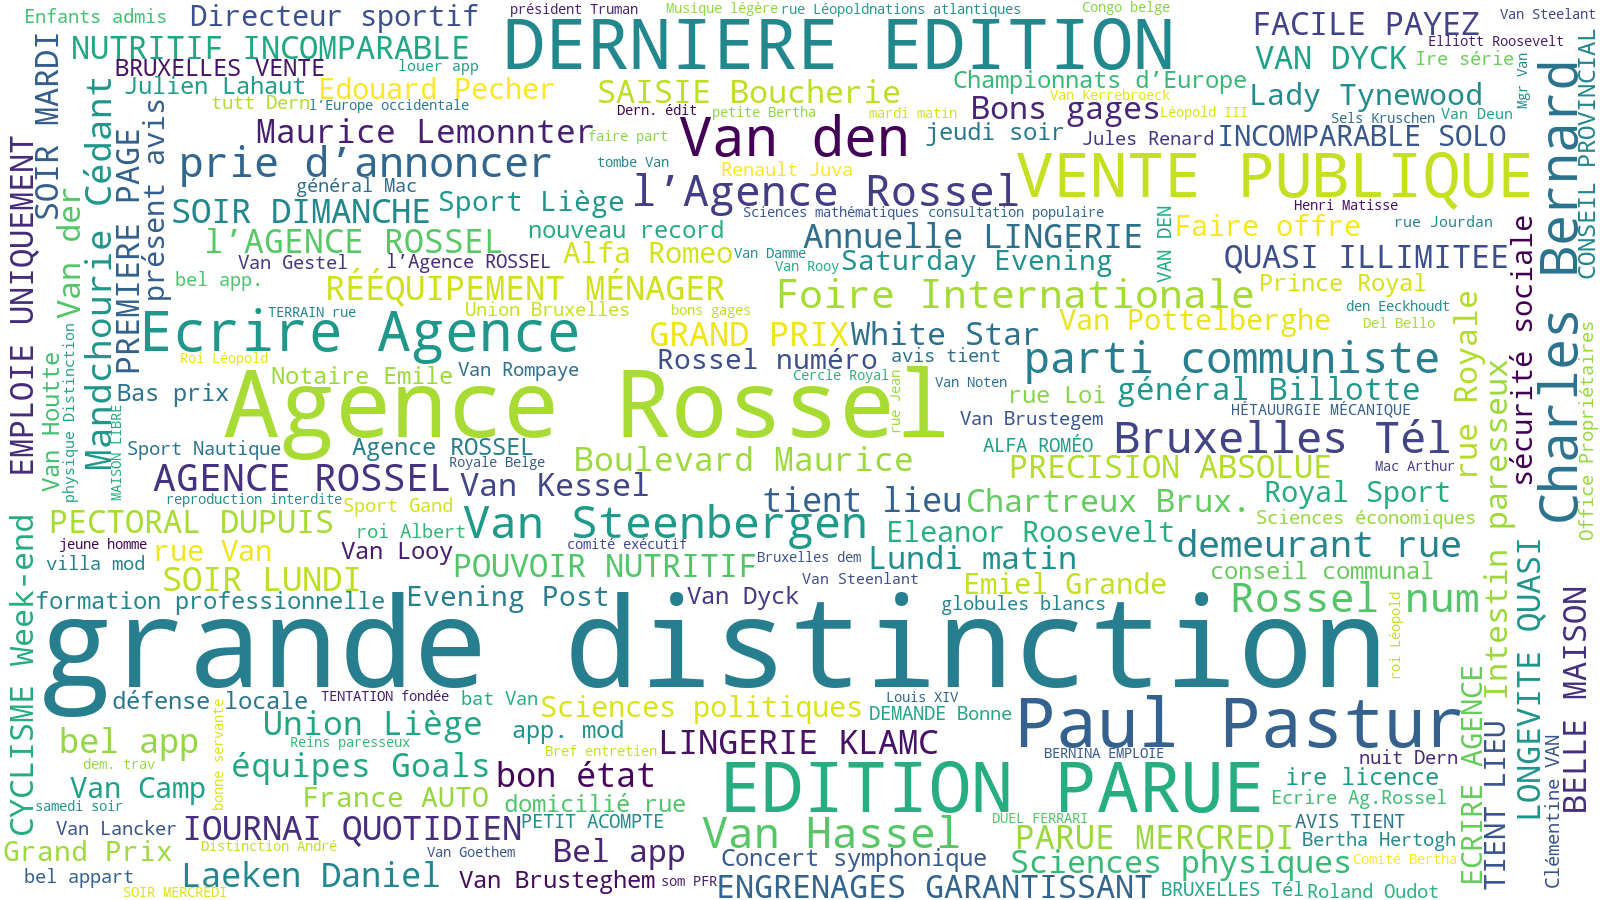

OK → /Users/iduoliveira/TACTEST/tac/tp2/figs/wordcloud_1950.png


In [5]:
wc = WordCloud(width=1600, height=900, background_color="white") \
        .generate_from_frequencies(freq)
wc.to_file(str(OUT_PNG))

display(Image(filename=str(OUT_PNG)))
print(f"OK → {OUT_PNG}")


In [ ]:
# Stopwords (Idem que dans s1)
sw = stopwords.words("french")
sw += ["les", "plus", "cette", "fait", "faire", "être", "deux", "comme", "dont", "tout",
       "ils", "bien", "sans", "peut", "tous", "après", "ainsi", "donc", "cet", "sous",
       "celle", "entre", "encore", "toutes", "pendant", "moins", "dire", "cela", "non",
       "faut", "trois", "aussi", "dit", "avoir", "doit", "contre", "depuis", "autres",
       "van", "het", "autre", "jusqu", "ville", "rossel", "dem"]
sw = set(sw)


## Créer un fichier contenant le texte de tous les journaux d'une année donnée

In [ ]:
# Choisir une année
year = 1945

In [ ]:
# Lister les fichiers de cette année
data_path = '../data'
txt_path = '../data/txt'
txts = [f for f in os.listdir(txt_path) if os.path.isfile(os.path.join(txt_path, f)) and str(year) in f]
len(txts)

In [ ]:
# Stocker le contenu de ces fichiers dans une liste
content_list = []
for txt in txts:
    with open(os.path.join(txt_path, txt), 'r', encoding='utf-8') as f:
        content_list.append(f.read())

In [ ]:
# Compter le nombre d'éléments (=fichiers) dans la liste
len(content_list)

In [ ]:
# Imprimer les 200 premiers caractères du contenu du premier fichier
content_list[0][0:200]

In [ ]:
# Ecrire tout le contenu dans un fichier temporaire
temp_path = '../data/tmp'
if not os.path.exists(temp_path):
    os.mkdir(temp_path)
with open(os.path.join(temp_path, f'{year}.txt'), 'w', encoding='utf-8') as f:
    f.write(' '.join(content_list))

In [ ]:
# Imprimer le contenu du fichier et constater les "déchets"
with open(os.path.join(temp_path, f'{year}.txt'), 'r', encoding='utf-8') as f:
    before = f.read()

before[:500]

## Nettoyer le fichier à l'aide d'une fonction de nettoyage

### Créer la fonction de nettoyage (à adapter)

In [ ]:
def clean_text(year, folder=None):
    if folder is None:
        input_path = f"{year}.txt"
        output_path = f"{year}_clean.txt"
    else:
        input_path = f"{folder}/{year}.txt"
        output_path = f"{folder}/{year}_clean.txt"
    output = open(output_path, "w", encoding='utf-8')
    with open(input_path, 'r', encoding='utf-8') as f:
        text = f.read()
        words = nltk.wordpunct_tokenize(text)
        kept = [w.upper() for w in words if len(w) > 2 and w.isalpha() and w.lower() not in sw]
        kept_string = " ".join(kept)
        output.write(kept_string)
    return f'Output has been written in {output_path}!'

### Appliquer la fonction sur le fichier complet de l'année

In [ ]:
clean_text(year, folder=temp_path)

In [ ]:
# Vérifier le résultat
with open(os.path.join(temp_path, f'{year}_clean.txt'), 'r', encoding='utf-8') as f:
    after = f.read()

after[:500]

## Nuage de mots

### Afficher les termes les plus fréquents


In [ ]:
frequencies = Counter(after.split())
print(frequencies.most_common(10))

### Créer, stocker et afficher le nuage de mots

In [ ]:
cloud = WordCloud(width=2000, height=1000, background_color='white').generate_from_frequencies(frequencies)
cloud.to_file(os.path.join(temp_path, f"{year}.png"))
Image(filename=os.path.join(temp_path, f"{year}.png"))